# Plot ERA5 Averaged Field With Basemap

This notebook reads an averaged ERA5 `.npy` field, gets latitude and longitude from a reference ERA5 NetCDF file, and plots the result on a Basemap map.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap
from mpl_toolkits.basemap import Basemap


def find_project_root(start=None):
    """Find the repository root when the notebook is run from root or notebooks/."""
    start = Path(start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / 'outputs').exists() and (path / 'data').exists():
            return path
    return start


PROJECT_ROOT = find_project_root()
NPY_FILE = PROJECT_ROOT / 'outputs' / 'era5_1946_1947_04_T_850.npy'
REFERENCE_FILE = PROJECT_ROOT / 'data' / 'era5' / '1946_1960' / 'ERA5_sfc_19460401T000000.000000000.nc'

print(f'Using field: {NPY_FILE}')
print(f'Using grid:  {REFERENCE_FILE}')

Using field: /geode3/home/u020/ckieu/BigRed200/model/diagnosePy/outputs/era5_1946_1947_04_T_850.npy
Using grid:  /geode3/home/u020/ckieu/BigRed200/model/diagnosePy/data/era5/1946_1960/ERA5_sfc_19460401T000000.000000000.nc


In [15]:
def _first_existing_name(dataset, names):
    for name in names:
        if name in dataset.coords or name in dataset.variables:
            return name
    raise KeyError(f'Could not find any of these coordinates: {names}')


def read_era5_grid(reference_file):
    """Read latitude and longitude arrays from a reference ERA5 NetCDF file."""
    with xr.open_dataset(reference_file) as ds:
        lat_name = _first_existing_name(ds, ('latitude', 'lat', 'XLAT', 'XLAT_M'))
        lon_name = _first_existing_name(ds, ('longitude', 'lon', 'XLONG', 'XLONG_M'))
        lat = np.asarray(ds[lat_name].squeeze().values)
        lon = np.asarray(ds[lon_name].squeeze().values)
    return lat, lon


def load_average_field(npy_file):
    """Load a 2-D averaged ERA5 field from a NumPy output file."""
    field = np.squeeze(np.load(npy_file))
    if field.ndim != 2:
        raise ValueError(f'Expected a 2-D field after squeeze, got shape {field.shape}')
    return field


def _prepare_rectilinear_grid(field, lat, lon):
    if lat.ndim != 1 or lon.ndim != 1:
        if field.shape != lat.shape or field.shape != lon.shape:
            raise ValueError('For 2-D lat/lon grids, lat, lon, and field must have the same shape.')
        return lon, lat, field

    if field.shape == (lon.size, lat.size):
        field = field.T
    elif field.shape != (lat.size, lon.size):
        raise ValueError(f'Field shape {field.shape} does not match lat/lon sizes {(lat.size, lon.size)}')

    if np.nanmax(lon) > 180.0:
        lon = ((lon + 180.0) % 360.0) - 180.0
        order = np.argsort(lon)
        lon = lon[order]
        field = field[:, order]

    if lat[0] > lat[-1]:
        lat = lat[::-1]
        field = field[::-1, :]

    lon2d, lat2d = np.meshgrid(lon, lat)
    return lon2d, lat2d, field


def _parse_domain(domain, lon2d, lat2d):
    if domain is None:
        return (
            float(np.nanmin(lon2d)),
            float(np.nanmax(lon2d)),
            float(np.nanmin(lat2d)),
            float(np.nanmax(lat2d)),
        )

    if isinstance(domain, dict):
        lon_min = domain['lon_min']
        lon_max = domain['lon_max']
        lat_min = domain['lat_min']
        lat_max = domain['lat_max']
    else:
        lon_min, lon_max, lat_min, lat_max = domain

    lon_min, lon_max = float(lon_min), float(lon_max)
    lat_min, lat_max = sorted((float(lat_min), float(lat_max)))
    if lon_min >= lon_max:
        raise ValueError('Use lon_min < lon_max. Dateline-crossing domains are not handled in this notebook.')
    return lon_min, lon_max, lat_min, lat_max


def _subset_domain(lon2d, lat2d, field, domain):
    lon_min, lon_max, lat_min, lat_max = _parse_domain(domain, lon2d, lat2d)
    mask = (lon2d >= lon_min) & (lon2d <= lon_max) & (lat2d >= lat_min) & (lat2d <= lat_max)
    if not np.any(mask):
        raise ValueError('The requested domain does not overlap the ERA5 grid.')

    rows = np.where(np.any(mask, axis=1))[0]
    cols = np.where(np.any(mask, axis=0))[0]
    row_slice = slice(rows.min(), rows.max() + 1)
    col_slice = slice(cols.min(), cols.max() + 1)
    return lon2d[row_slice, col_slice], lat2d[row_slice, col_slice], field[row_slice, col_slice], (lon_min, lon_max, lat_min, lat_max)


def _build_levels(field, shading_levels=None, level_count=21):
    if shading_levels is None:
        vmin = float(np.nanmin(field))
        vmax = float(np.nanmax(field))
        if np.isclose(vmin, vmax):
            vmin -= 0.5
            vmax += 0.5
        shading_levels = np.linspace(vmin, vmax, int(level_count))
    else:
        shading_levels = np.asarray(shading_levels, dtype=float)

    if shading_levels.ndim != 1 or shading_levels.size < 2:
        raise ValueError('shading_levels must contain at least two values.')
    if not np.all(np.diff(shading_levels) > 0):
        raise ValueError('shading_levels must be strictly increasing.')
    return shading_levels


def _build_interval_cmap(levels, lower_color='royalblue', upper_color='firebrick', lowest_interval_white=False):
    interval_count = max(len(levels) - 1, 1)
    base = LinearSegmentedColormap.from_list('era5_shading', [lower_color, upper_color])
    colors = base(np.linspace(0.0, 1.0, interval_count))
    if lowest_interval_white:
        colors[0] = (1.0, 1.0, 1.0, 1.0)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(levels, cmap.N)
    return cmap, norm


def plot_era5_average_field(
    npy_file,
    reference_file,
    *,
    domain=None,
    shading_levels=None,
    level_count=21,
    lower_color='royalblue',
    upper_color='firebrick',
    lowest_interval_white=False,
    add_contours=False,
    contour_levels=None,
    contour_count=7,
    contour_colors='black',
    contour_linewidths=0.8,
    contour_labels=True,
    contour_label_fontsize=8,
    xlabel='Longitude',
    ylabel='Latitude',
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    xtick_fontsize=10,
    ytick_fontsize=10,
    x_tick_count=7,
    y_tick_count=7,
    title=None,
    title_fontsize=13,
    cbar_label=None,
    cbar_label_fontsize=11,
    cbar_tick_fontsize=9,
    figsize=(12, 6),
    map_resolution='c',
    coastline_linewidth=0.6,
    country_linewidth=0.4,
    extend='both',
):
    """Plot an averaged ERA5 npy field on a latitude-longitude Basemap map.

    Parameters
    ----------
    domain : tuple, dict, or None
        Use (lon_min, lon_max, lat_min, lat_max), for example (-180, 180, -90, 90).
        A dict with lon_min/lon_max/lat_min/lat_max is also accepted.
    shading_levels : sequence or None
        Specific color interval boundaries for the shaded field. If None, level_count
        evenly spaced intervals are created from the plotted data range.
    lowest_interval_white : bool
        If True, the first shaded interval is colored white.
    add_contours : bool
        If True, contour lines of the same field are overlaid.
    """
    field = load_average_field(npy_file)
    lat, lon = read_era5_grid(reference_file)
    lon2d, lat2d, field = _prepare_rectilinear_grid(field, lat, lon)
    lon_plot, lat_plot, field_plot, map_domain = _subset_domain(lon2d, lat2d, field, domain)
    lon_min, lon_max, lat_min, lat_max = map_domain

    levels = _build_levels(field_plot, shading_levels=shading_levels, level_count=level_count)
    cmap, norm = _build_interval_cmap(levels, lower_color=lower_color, upper_color=upper_color, lowest_interval_white=lowest_interval_white)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    basemap = Basemap(
        projection='cyl',
        llcrnrlon=lon_min,
        urcrnrlon=lon_max,
        llcrnrlat=lat_min,
        urcrnrlat=lat_max,
        resolution=map_resolution,
        ax=ax,
    )

    x, y = basemap(lon_plot, lat_plot)
    shade = basemap.contourf(x, y, field_plot, levels=levels, cmap=cmap, norm=norm, extend=extend)
    basemap.drawcoastlines(linewidth=coastline_linewidth)
    basemap.drawcountries(linewidth=country_linewidth)
    basemap.drawmapboundary(linewidth=0.6)

    contour_set = None
    if add_contours:
        if contour_levels is None:
            contour_levels = np.linspace(levels[0], levels[-1], int(contour_count))
        contour_set = basemap.contour(x, y, field_plot, levels=contour_levels, colors=contour_colors, linewidths=contour_linewidths)
        if contour_labels:
            ax.clabel(contour_set, inline=True, fontsize=contour_label_fontsize, fmt='%g')

    cbar = fig.colorbar(shade, ax=ax, pad=0.02, shrink=0.88)
    if cbar_label:
        cbar.set_label(cbar_label, fontsize=cbar_label_fontsize)
    cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    #ax.set_xticks(np.linspace(lon_min, lon_max, int(x_tick_count)))
    #ax.set_yticks(np.linspace(lat_min, lat_max, int(y_tick_count)))
    ax.set_yticks([0, 10, 20, 30])
    ax.set_xticks([100, 110, 120, 130, 140, 150])
    ax.tick_params(axis='x', labelsize=xtick_fontsize)
    ax.tick_params(axis='y', labelsize=ytick_fontsize)
    ax.grid(True, linewidth=0.25, color='0.65', alpha=0.5)

    if title:
        ax.set_title(title, fontsize=title_fontsize)

    return fig, ax, basemap, shade, contour_set


Saved /geode3/home/u020/ckieu/BigRed200/model/diagnosePy/outputs/era5_1946_1947_04_T_850_map.png


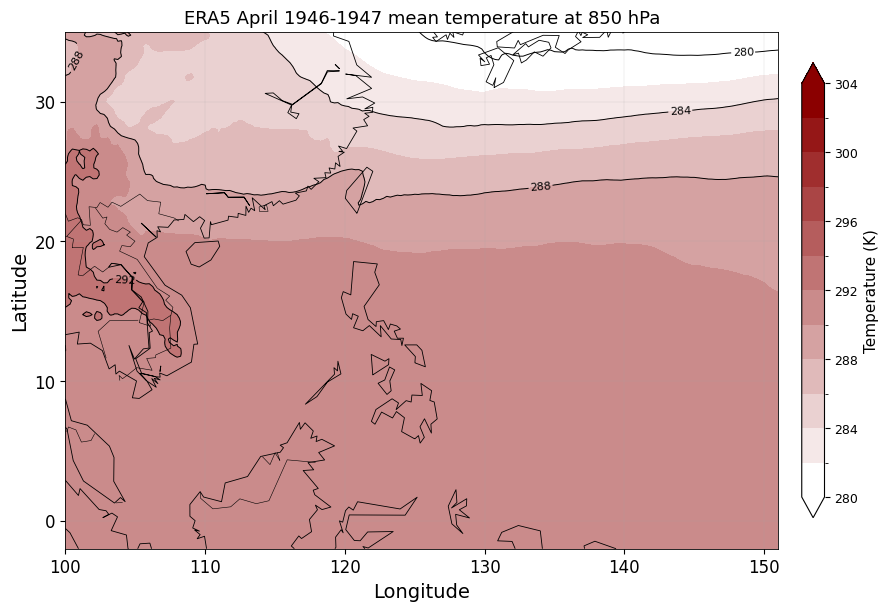

In [21]:
temperature_levels = np.arange(280, 305, 2)
contour_levels = np.arange(240, 301, 4)

fig, ax, basemap, shade, contours = plot_era5_average_field(
    NPY_FILE,
    REFERENCE_FILE,
    domain=(100, 151, -2, 35),
    shading_levels=temperature_levels,
    lower_color='white',
    upper_color='darkred',
    lowest_interval_white=True,
    add_contours=True,
    contour_levels=contour_levels,
    contour_colors='black',
    contour_linewidths=0.7,
    xlabel_fontsize=14,
    ylabel_fontsize=14,
    xtick_fontsize=12,
    ytick_fontsize=12,
    x_tick_count=6,
    y_tick_count=6,
    title='ERA5 April 1946-1947 mean temperature at 850 hPa',
    cbar_label='Temperature (K)',
)

output_figure = PROJECT_ROOT / 'outputs' / 'era5_1946_1947_04_T_850_map.png'
fig.savefig(output_figure, dpi=150, bbox_inches='tight')
print(f'Saved {output_figure}')
plt.show()